# 📘 Chapter 3: Classification
### *Hands-On ML with Scikit-Learn, Keras & TensorFlow — Aurélien Géron*

---

> **What this chapter covers:**
> Classification is one of the most common ML tasks — predicting which *category* something belongs to.
> We'll use the famous **MNIST handwritten digits dataset** throughout.

> 🗺️ **Chapter Roadmap:**
> 1. The MNIST dataset — what it looks like
> 2. Binary classification — is it a "5" or not?
> 3. Performance measures — accuracy, confusion matrix, precision, recall, F1
> 4. The Precision/Recall tradeoff
> 5. The ROC curve & AUC
> 6. Multiclass classification
> 7. Error analysis
> 8. Multilabel & multioutput classification

---


## 🔧 Setup — Imports

In [1]:
import numpy as np                          # NumPy: fast numerical arrays and maths
import pandas as pd                          # Pandas: data tables (DataFrames)
import matplotlib.pyplot as plt              # Matplotlib: plotting library
import matplotlib as mpl                     # Matplotlib config (used for colour maps etc.)
import seaborn as sns                        # Seaborn: prettier statistical plots built on matplotlib
import warnings                              # Python built-in: control warning messages
warnings.filterwarnings('ignore')            # Suppress noisy warnings so output stays clean

from sklearn.datasets import fetch_openml            # Function to download datasets from OpenML
from sklearn.linear_model import SGDClassifier, LogisticRegression  # Two linear classifiers
from sklearn.ensemble import RandomForestClassifier  # Ensemble of many decision trees
from sklearn.multiclass import OneVsRestClassifier   # Wraps binary classifiers for multiclass tasks
from sklearn.preprocessing import StandardScaler     # Scales features to mean=0, std=1
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
# cross_val_score     → evaluate a model using k-fold cross-validation
# cross_val_predict   → get out-of-fold predictions (used to build confusion matrices fairly)
# StratifiedKFold     → k-fold that preserves class proportions in each fold
from sklearn.metrics import (confusion_matrix,       # Counts TP/TN/FP/FN
                              precision_score,        # TP / (TP + FP)
                              recall_score,           # TP / (TP + FN)
                              f1_score,               # Harmonic mean of precision & recall
                              precision_recall_curve, # Precision & recall at every threshold
                              roc_curve,              # TPR vs FPR at every threshold
                              roc_auc_score,          # Area under the ROC curve
                              classification_report,  # Full per-class metric table
                              ConfusionMatrixDisplay)  # Helper to plot a confusion matrix
from sklearn.pipeline import Pipeline                # Chains preprocessing + model into one object

plt.rcParams['figure.facecolor'] = 'white'   # Set plot background to white
plt.rcParams['axes.facecolor']   = '#f8f9fa' # Set axes background to light grey
plt.rcParams['axes.grid']        = True      # Show gridlines on all plots
plt.rcParams['grid.alpha']       = 0.3       # Make gridlines subtle (30% opacity)

print("✅ All imports successful!")


✅ All imports successful!


## 1. 🖊️ The MNIST Dataset

> 🟦 **MNIST:** A dataset of 70,000 handwritten digit images (0–9), each 28×28 pixels.
> It's the "Hello World" of machine learning — used to benchmark almost every classification algorithm.

| Property | Value |
|---|---|
| Total images | 70,000 |
| Training set | 60,000 |
| Test set | 10,000 |
| Image size | 28 × 28 pixels = 784 features |
| Classes | 10 (digits 0–9) |

Each image is flattened into a vector of **784 pixel intensity values** (0 = white, 255 = black).


In [2]:
# Load MNIST — this may take a minute the first time (downloads ~11MB)
from sklearn.datasets import fetch_openml  # Function to download datasets from OpenML
import numpy as np                         # NumPy for array operations

print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
# fetch_openml      → downloads the MNIST dataset from the internet
# 'mnist_784'       → the dataset name (784 = 28×28 pixels flattened)
# version=1         → use version 1 (stable, well-known split)
# as_frame=False    → return NumPy arrays instead of a Pandas DataFrame
# parser='auto'     → let sklearn pick the best parser for the file format

X, y = mnist.data, mnist.target.astype(np.uint8)
# mnist.data        → X: shape (70000, 784) — each row is one image as 784 pixel values
# mnist.target      → y: the digit label (0–9) for each image, stored as a string by default
# .astype(np.uint8) → convert labels from string to integer (uint8 = unsigned 8-bit int, range 0–255)

# Standard train/test split used in the book (and the MNIST convention)
X_train, X_test = X[:60000], X[60000:]   # First 60k images for training, last 10k for testing
y_train, y_test = y[:60000], y[60000:]   # Same split for labels

print(f"✅ Loaded!")
print(f"   X shape: {X.shape}  → {X.shape[0]:,} images, each with {X.shape[1]} pixel features")
print(f"   y shape: {y.shape}  → labels 0–9")
print(f"   Training: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"   Pixel value range: {X.min():.0f} – {X.max():.0f}")


Loading MNIST dataset...
✅ Loaded!
   X shape: (70000, 784)  → 70,000 images, each with 784 pixel features
   y shape: (70000,)  → labels 0–9
   Training: 60,000 | Test: 10,000
   Pixel value range: 0 – 255


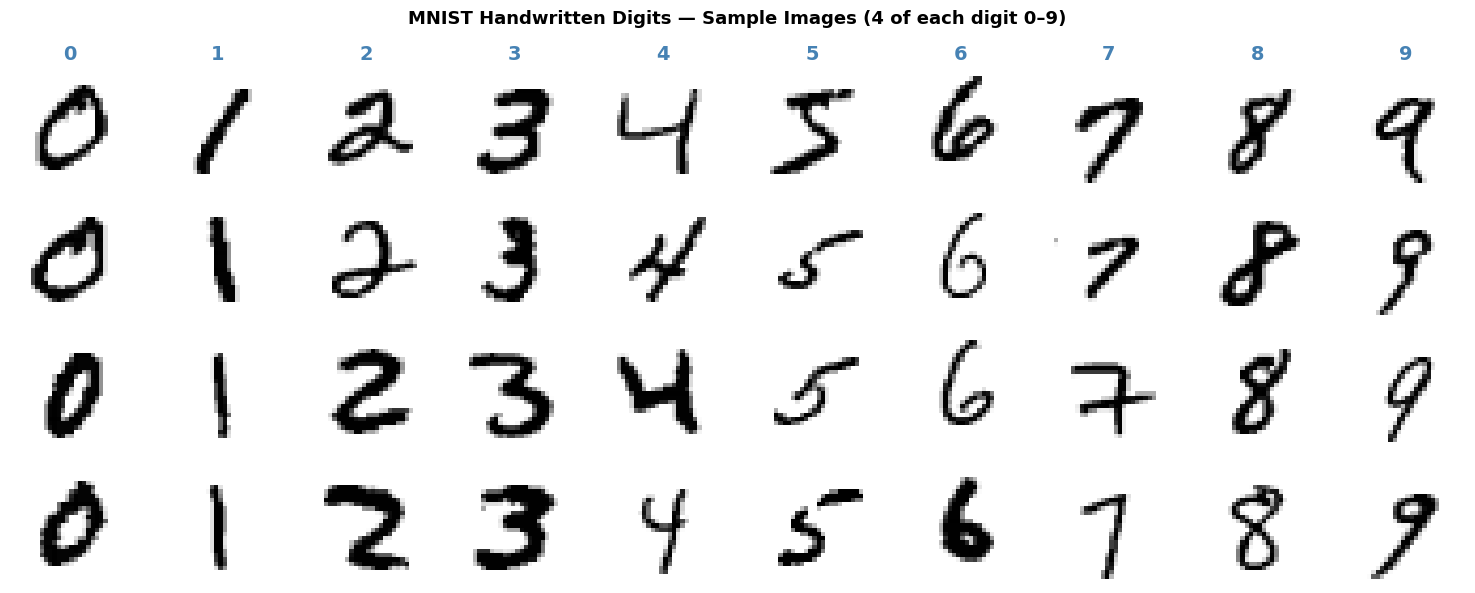

💡 Each image is 28×28 = 784 pixel values. The model never 'sees' the image —
   it sees a row of 784 numbers ranging from 0 (white) to 255 (black).


In [3]:
# Visualise sample digits — what does the data look like?
fig, axes = plt.subplots(4, 10, figsize=(15, 6))
# plt.subplots(4, 10) → create a grid of 4 rows × 10 columns of subplots (one column per digit)
# figsize=(15, 6)     → figure is 15 inches wide, 6 inches tall

fig.suptitle("MNIST Handwritten Digits — Sample Images (4 of each digit 0–9)",
             fontsize=13, fontweight='bold')  # Main title above all subplots

for digit in range(10):                              # Loop over each digit class 0–9
    idxs = np.where(y_train == digit)[0][:4]         # Find indices of the first 4 training images of this digit
    for row, idx in enumerate(idxs):                 # Loop over those 4 samples
        ax = axes[row, digit]                        # Select the subplot at this row & column
        ax.imshow(X_train[idx].reshape(28, 28),      # Reshape flat 784-pixel vector back to 28×28 image
                  cmap='binary',                     # 'binary' colourmap: black digits on white background
                  interpolation='nearest')           # No smoothing — keep pixel edges sharp
        ax.axis('off')                               # Hide x/y axis ticks and labels
        if row == 0:                                 # Only add digit label on the top row
            ax.set_title(str(digit), fontsize=14, fontweight='bold', color='steelblue')

plt.tight_layout()                                              # Auto-adjust spacing so subplots don't overlap
plt.savefig("ch03_01_mnist_samples.png", dpi=150, bbox_inches='tight')  # Save to file at 150 DPI
plt.show()                                                      # Display the figure
print("💡 Each image is 28×28 = 784 pixel values. The model never 'sees' the image —")
print("   it sees a row of 784 numbers ranging from 0 (white) to 255 (black).")


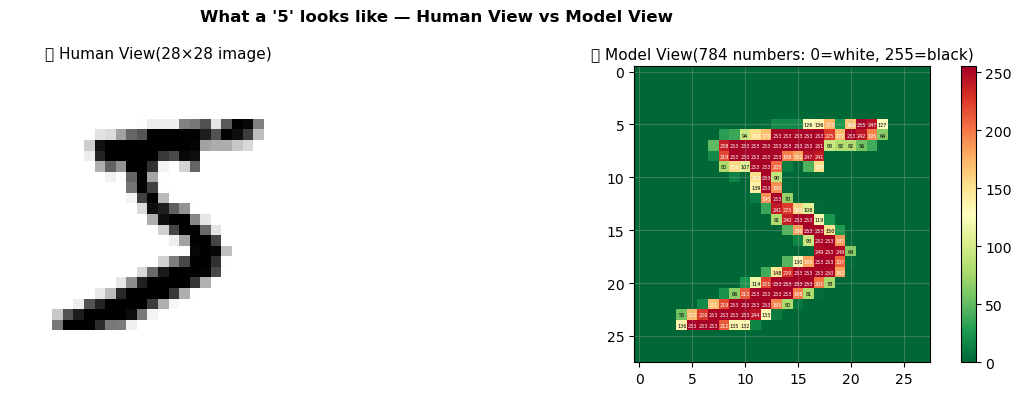

In [5]:
# Show what the raw data looks like to the model
sample_idx = np.where(y_train == 5)[0][0]   # Find the index of the first '5' in the training set
image = X_train[sample_idx].reshape(28, 28) # Reshape the flat 784-value row into a 28×28 grid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Two side-by-side subplots
fig.suptitle("What a '5' looks like — Human View vs Model View", fontsize=12, fontweight='bold')

# ── Left panel: how a human sees it ─────────────────────────────────────
ax = axes[0]
ax.imshow(image, cmap='binary', interpolation='nearest')  # Show as a black-and-white image
ax.set_title("👁️ Human View(28×28 image)", fontsize=11)
ax.axis('off')                                             # No axes needed for an image

# ── Right panel: the actual numbers the model receives ──────────────────
ax = axes[1]
im = ax.imshow(image, cmap='RdYlGn_r',    # Colour map: red=high value (dark pixel), green=low
               interpolation='nearest',
               vmin=0, vmax=255)           # Fix colour scale from 0 (white) to 255 (black)
for i in range(28):                        # Loop over each row of pixels
    for j in range(28):                    # Loop over each column of pixels
        val = int(image[i, j])             # Get the pixel intensity (0–255)
        if val > 50:                       # Only annotate non-background pixels (avoid clutter)
            ax.text(j, i, str(val),        # Place the number at pixel position (j, i)
                    ha='center', va='center',
                    fontsize=3.5,          # Very small font to fit inside each pixel cell
                    color='white' if val > 150 else 'black')  # White text on dark pixels, black on light
plt.colorbar(im, ax=ax, fraction=0.046)    # Add a colour bar to show the 0–255 scale
ax.set_title("🤖 Model View(784 numbers: 0=white, 255=black)", fontsize=11)

plt.tight_layout()
plt.savefig("ch03_02_pixel_view.png", dpi=150, bbox_inches='tight')
plt.show()


## 2. 🔢 Binary Classification — "Is it a 5?"

We start simple: instead of classifying all 10 digits, we ask one yes/no question:
**"Is this image a 5?"**

> 🟦 **Binary Classification:** Classifying instances into exactly two classes.
> Examples: spam/not-spam, fraud/legitimate, 5/not-5

### Algorithm: SGD Classifier

> 🟦 **SGD (Stochastic Gradient Descent) Classifier:** A fast, scalable linear classifier.
> "Stochastic" means it uses one random training sample at a time to update weights,
> rather than the full dataset. Very efficient for large datasets.

> 🟦 **Gradient Descent:** An optimisation algorithm that iteratively adjusts model
> parameters in the direction that reduces error — like rolling a ball downhill to find the lowest point.


Training set class distribution:
  '5' (positive class):     5,421  (9.0%)
  'not 5' (negative class): 54,579  (91.0%)

⚠️  Note: Only ~10% of digits are '5' — this is a CLASS IMBALANCE problem!
   This is why accuracy alone can be misleading (see next section).


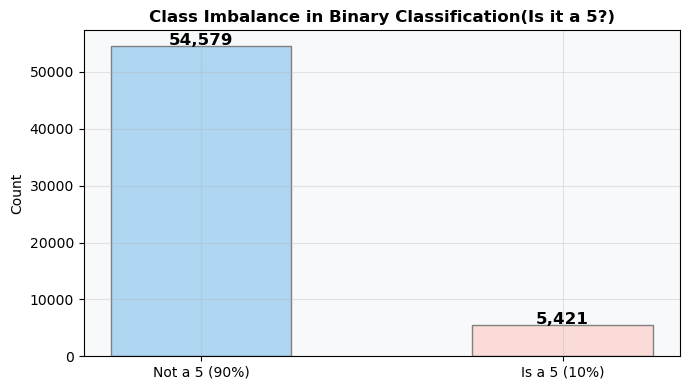

In [6]:
# Create binary labels: True if digit is 5, False otherwise
y_train_5 = (y_train == 5)    # Boolean array: True where label is 5, False everywhere else
y_test_5  = (y_test == 5)     # Same for the test set

print(f"Training set class distribution:")
print(f"  '5' (positive class):     {y_train_5.sum():,}  ({y_train_5.mean()*100:.1f}%)")
# .sum()  → counts True values (number of 5s)
# .mean() → proportion of True values (fraction that are 5s)
print(f"  'not 5' (negative class): {(~y_train_5).sum():,}  ({(~y_train_5).mean()*100:.1f}%)")
# ~y_train_5 → bitwise NOT — flips True/False to count the non-5s
print()
print("⚠️  Note: Only ~10% of digits are '5' — this is a CLASS IMBALANCE problem!")
print("   This is why accuracy alone can be misleading (see next section).")

# Visualise class distribution
fig, ax = plt.subplots(figsize=(7, 4))
classes = ['Not a 5 (90%)', 'Is a 5 (10%)']          # Human-readable class labels
counts  = [(~y_train_5).sum(), y_train_5.sum()]        # Count of each class
colors  = ['#AED6F1', '#FADBD8']                       # Light blue for majority, light red for minority
bars = ax.bar(classes, counts, color=colors, edgecolor='gray', width=0.5)  # Draw bars
ax.set_title("Class Imbalance in Binary Classification(Is it a 5?)", fontsize=12, fontweight='bold')
ax.set_ylabel("Count")
for bar, count in zip(bars, counts):                   # Loop over bars to add count labels on top
    ax.text(bar.get_x() + bar.get_width()/2,           # Horizontal centre of the bar
            bar.get_height() + 200,                    # Just above the top of the bar
            f'{count:,}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("ch03_03_class_imbalance.png", dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# Train the SGD binary classifier
from sklearn.linear_model import SGDClassifier   # Fast linear classifier using stochastic gradient descent
from sklearn.preprocessing import StandardScaler # Scales features to zero mean, unit variance
from sklearn.pipeline import Pipeline            # Chains steps together so they run in sequence

sgd_pipeline = Pipeline([
    ('scaler', StandardScaler()),                # Step 1: scale pixels to mean=0, std=1
    # SGD is sensitive to feature scale — large pixel values (0–255) would slow learning
    ('sgd', SGDClassifier(random_state=42,       # random_state=42 → reproducible results
                          max_iter=1000))        # max_iter → maximum number of passes over training data
])

print("Training SGD Classifier on 60,000 images...")
sgd_pipeline.fit(X_train, y_train_5)  # Fit the full pipeline: scale then train on binary labels
print("✅ Done!")

# Test on a sample image to check the model works
sample_5    = X_train[y_train == 5][0]   # First training image that IS a 5
sample_not5 = X_train[y_train == 3][0]  # First training image that is a 3 (not a 5)

pred_5    = sgd_pipeline.predict([sample_5])[0]    # Predict: is this a 5? (returns True/False)
pred_not5 = sgd_pipeline.predict([sample_not5])[0] # Predict: is this a 5?

print()
print(f"Prediction for a '5' image:   {'✅ 5' if pred_5 else '❌ Not 5'}")
print(f"Prediction for a '3' image:   {'❌ 5' if pred_not5 else '✅ Not 5'}")


Training SGD Classifier on 60,000 images...
✅ Done!

Prediction for a '5' image:   ❌ Not 5
Prediction for a '3' image:   ✅ Not 5


## 3. 📏 Performance Measures

> 🟨 **Key Takeaway:** Accuracy is almost always the WRONG metric for classification — especially with imbalanced classes.

### Why accuracy fails:

Imagine a classifier that **always predicts "Not a 5"**. Since only 10% of images are 5s, it would be correct 90% of the time. That's 90% accuracy — but it's completely useless!

This is the **accuracy paradox**.

---

### The Confusion Matrix 🟥🟦

> 🟦 **Confusion Matrix:** A table showing how many instances were correctly and incorrectly classified.

```
                  Predicted: NOT 5    Predicted: IS 5
Actual: NOT 5   [ True Negative  (TN)   False Positive (FP) ]
Actual: IS 5    [ False Negative (FN)   True Positive  (TP) ]
```

| Cell | Name | Meaning |
|---|---|---|
| TN | True Negative | Correctly said "Not a 5" |
| FP | False Positive | Wrongly said "Is a 5" (Type I Error) |
| FN | False Negative | Wrongly said "Not a 5" (Type II Error) |
| TP | True Positive | Correctly said "Is a 5" |


Computing cross-validated predictions (this takes ~30 seconds)...
✅ Done!

  CONFUSION MATRIX

  True  Negatives (TN): 53,927  ✅ Correctly said NOT 5
  False Positives (FP): 652  ❌ Said 5, was actually NOT 5
  False Negatives (FN): 1,228  ❌ Said NOT 5, was actually 5
  True  Positives (TP): 4,193  ✅ Correctly said IS 5



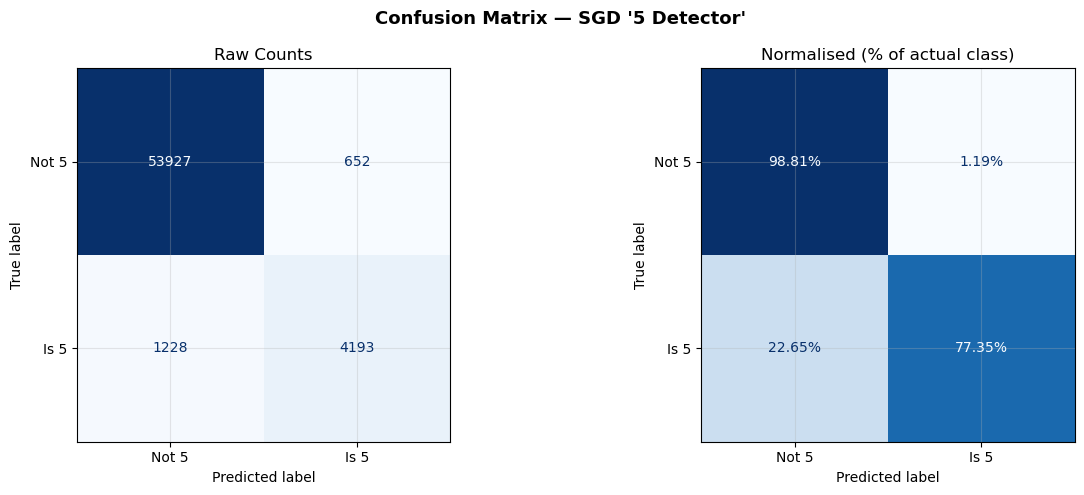

In [8]:
# Compute confusion matrix using cross-validation predictions
from sklearn.model_selection import cross_val_predict    # Generates out-of-fold predictions
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

print("Computing cross-validated predictions (this takes ~30 seconds)...")
y_train_pred = cross_val_predict(sgd_pipeline, X_train, y_train_5, cv=3)
# cross_val_predict  → splits training data into 3 folds; for each fold,
#                      trains on the other 2, then predicts on the held-out fold
# This gives us predictions for EVERY training sample without the model having seen it,
# which makes the confusion matrix more realistic (avoids overfitting bias)
print("✅ Done!")

cm = confusion_matrix(y_train_5, y_train_pred)
# confusion_matrix(true_labels, predicted_labels)
# Returns a 2×2 matrix: [[TN, FP], [FN, TP]]
tn, fp, fn, tp = cm.ravel()
# .ravel() → flatten the 2×2 matrix into [TN, FP, FN, TP] for easy unpacking

print()
print("=" * 50)
print("  CONFUSION MATRIX")
print("=" * 50)
print()
print(f"  True  Negatives (TN): {tn:,}  ✅ Correctly said NOT 5")
print(f"  False Positives (FP): {fp:,}  ❌ Said 5, was actually NOT 5")
print(f"  False Negatives (FN): {fn:,}  ❌ Said NOT 5, was actually 5")
print(f"  True  Positives (TP): {tp:,}  ✅ Correctly said IS 5")
print()

# ── Visual confusion matrix ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrix — SGD '5 Detector'", fontsize=13, fontweight='bold')

# Raw counts version
disp = ConfusionMatrixDisplay(cm, display_labels=['Not 5', 'Is 5'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')  # cmap='Blues' → darker = higher count
axes[0].set_title("Raw Counts", fontsize=12)

# Normalised version — divide each row by its total to get rates instead of counts
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
# cm.astype(float)  → convert to float so division gives decimals not integers
# .sum(axis=1, keepdims=True) → sum each row (axis=1), keep shape for broadcasting
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=['Not 5', 'Is 5'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')  # Show as percentages
axes[1].set_title("Normalised (% of actual class)", fontsize=12)

plt.tight_layout()
plt.savefig("ch03_04_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


### Precision, Recall, and F1 Score

> 🟦 **Precision:** Of all the times I predicted "5", how often was I right?
> $$Precision = \frac{TP}{TP + FP}$$

> 🟦 **Recall (Sensitivity):** Of all the actual 5s, how many did I catch?
> $$Recall = \frac{TP}{TP + FN}$$

> 🟦 **F1 Score:** The harmonic mean of precision and recall. Useful when you want a single score that balances both.
> $$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

### Intuition with real examples:

| Scenario | You care more about... | Use... |
|---|---|---|
| Cancer screening | Recall (don't miss any cancer) | Maximise Recall |
| YouTube recommendations | Precision (don't show rubbish) | Maximise Precision |
| Spam filter | Balance of both | F1 Score |
| Fraud detection | Recall (catch all fraud) | Maximise Recall |


  CLASSIFICATION METRICS
  Accuracy:  0.9687  (96.9%)
             ⚠️  Misleading! A 'never predict 5' model = 90% accuracy

  Precision: 0.8654  (86.5%)
             → When I say '5', I'm right 86.5% of the time

  Recall:    0.7735  (77.3%)
             → I catch 77.3% of all actual 5s

  F1 Score:  0.8169  (81.7%)
             → Balanced measure of precision & recall


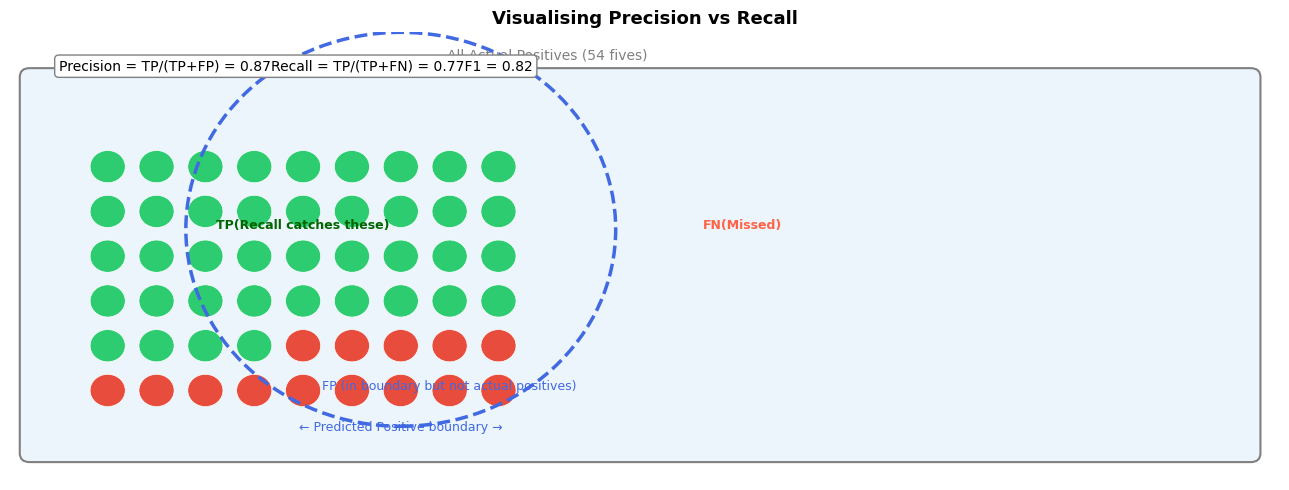

In [9]:
# Calculate and visualise precision, recall and F1
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

precision = precision_score(y_train_5, y_train_pred)
# precision_score → TP / (TP + FP): of all predicted positives, what fraction are correct?
recall    = recall_score(y_train_5, y_train_pred)
# recall_score    → TP / (TP + FN): of all actual positives, what fraction did we find?
f1        = f1_score(y_train_5, y_train_pred)
# f1_score        → 2 × (precision × recall) / (precision + recall): harmonic mean of both
accuracy  = (y_train_pred == y_train_5).mean()
# Accuracy: fraction of ALL predictions (both classes) that were correct

print("=" * 50)
print("  CLASSIFICATION METRICS")
print("=" * 50)
print(f"  Accuracy:  {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"             ⚠️  Misleading! A 'never predict 5' model = 90% accuracy")
print()
print(f"  Precision: {precision:.4f}  ({precision*100:.1f}%)")
print(f"             → When I say '5', I'm right {precision*100:.1f}% of the time")
print()
print(f"  Recall:    {recall:.4f}  ({recall*100:.1f}%)")
print(f"             → I catch {recall*100:.1f}% of all actual 5s")
print()
print(f"  F1 Score:  {f1:.4f}  ({f1*100:.1f}%)")
print(f"             → Balanced measure of precision & recall")

# ── Visual diagram showing what precision vs recall measures ─────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.set_xlim(0, 13); ax.set_ylim(0, 5); ax.axis('off')  # Set canvas size, hide axes
ax.set_title("Visualising Precision vs Recall", fontsize=13, fontweight='bold')

from matplotlib.patches import Ellipse, FancyBboxPatch

# Draw the outer "universe" box representing all training samples
ax.add_patch(FancyBboxPatch((0.2, 0.3), 12.5, 4.2,
             boxstyle="round,pad=0.1", fc='#EBF5FB', ec='gray', lw=1.5))

# Draw dots representing all actual positive samples (true 5s)
for i in range(54):                                    # 54 total simulated positives
    x = 1 + (i % 9) * 0.5                             # Arrange in a grid: column = i mod 9
    y = 3.5 - (i // 9) * 0.5                          # Row = i divided by 9
    color = '#2ECC71' if i < 40 else '#E74C3C'         # Green = TP (caught), Red = FN (missed)
    ax.add_patch(plt.Circle((x, y), 0.18, fc=color, ec='white', lw=0.5))

ax.text(5.5, 4.7, "All Actual Positives (54 fives)", ha='center', fontsize=10, color='gray')

# Draw the predicted-positive boundary (the model's "net")
ax.add_patch(plt.Circle((4.0, 2.8), 2.2,
             fc='none',              # No fill — just a border
             ec='royalblue', lw=2.5, linestyle='--'))  # Dashed blue circle = prediction boundary
ax.text(4.0, 0.55, "← Predicted Positive boundary →", ha='center', fontsize=9, color='royalblue')

# Labels explaining each region
ax.text(3.0, 2.8, f"TP(Recall catches these)", ha='center', 
        fontsize=9, color='darkgreen', fontweight='bold')    # Inside boundary + actual positive = TP
ax.text(7.5, 2.8, f"FN(Missed)", ha='center', fontsize=9, color='tomato', fontweight='bold')
# Outside boundary + actual positive = FN (missed by the model)
ax.text(4.5, 1.0, f"FP (in boundary but not actual positives)", ha='center',
        fontsize=9, color='royalblue')           # Inside boundary + actually negative = FP

# Score box in corner
ax.text(0.5, 4.7,f"Precision = TP/(TP+FP) = {precision:.2f}Recall = TP/(TP+FN) = {recall:.2f}F1 = {f1:.2f}",
        fontsize=10, va='top',
        bbox=dict(boxstyle='round', fc='white', ec='gray'))

plt.tight_layout()
plt.savefig("ch03_05_precision_recall_viz.png", dpi=150, bbox_inches='tight')
plt.show()


## 4. ⚖️ The Precision / Recall Tradeoff

> 🟨 **Key Insight:** You can't maximise both precision AND recall at the same time. Increasing one usually decreases the other.

### How classifiers make decisions — the decision threshold

SGD doesn't directly predict "5" or "not 5". It first computes a **decision score** for each instance, then compares it to a **threshold**:

- Score > threshold → predict "5"
- Score ≤ threshold → predict "not 5"

**Raising the threshold:**
- Fewer positives predicted → Precision ↑, Recall ↓

**Lowering the threshold:**
- More positives predicted → Recall ↑, Precision ↓

> 🟦 **Precision-Recall Curve:** A plot showing how precision and recall change as you vary the threshold. Helps you choose the right threshold for your use case.


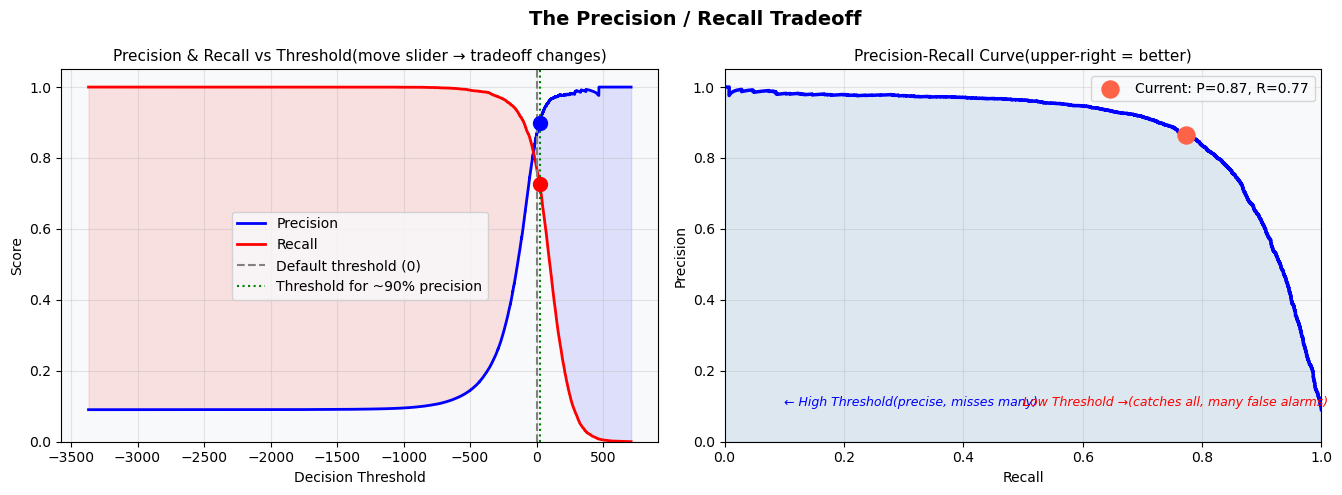

💡 A perfect classifier would have a PR curve that reaches (1, 1) — top right corner!


In [10]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Get continuous decision scores instead of hard True/False predictions
# The SGD model internally computes a score; we threshold it to get a binary prediction
sgd_model = sgd_pipeline.named_steps['sgd']      # Extract the trained SGD model from the pipeline
scaler    = sgd_pipeline.named_steps['scaler']   # Extract the trained scaler from the pipeline
X_train_scaled = scaler.transform(X_train)       # Apply scaling to training data (transform, not fit!)
# We use transform (not fit_transform) here to avoid re-fitting the scaler on training data

y_scores = cross_val_predict(sgd_model, X_train_scaled, y_train_5,
                              cv=3, method='decision_function')
# method='decision_function' → return raw scores instead of binary labels
# These scores reflect how confident the model is that each image is a 5
# Higher score = more confident it's a 5; lower score = more confident it's not

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
# precision_recall_curve → computes precision and recall at every possible threshold
# precisions[i] = precision if threshold = thresholds[i]
# recalls[i]    = recall    if threshold = thresholds[i]
# Note: len(thresholds) = len(precisions) - 1 (last precision has no matching threshold)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("The Precision / Recall Tradeoff", fontsize=14, fontweight='bold')

# ── Left: precision & recall as a function of threshold ─────────────────
ax = axes[0]
ax.plot(thresholds, precisions[:-1], 'b-', lw=2, label='Precision')  # Drop last precision (no threshold)
ax.plot(thresholds, recalls[:-1],    'r-', lw=2, label='Recall')

ax.axvline(0, color='gray', lw=1.5, linestyle='--', label='Default threshold (0)')
# Default threshold = 0: predict 5 if score > 0, not-5 otherwise

# Find the threshold where precision first reaches 90%
high_prec_idx = np.argmax(precisions >= 0.90)   # np.argmax returns the first index where condition is True
if high_prec_idx < len(thresholds):             # Guard: make sure index is valid
    ax.axvline(thresholds[high_prec_idx], color='green', lw=1.5,
               linestyle=':', label=f'Threshold for ~90% precision')
    ax.scatter([thresholds[high_prec_idx]], [precisions[high_prec_idx]],
               s=100, color='blue', zorder=5)    # Mark precision point on curve
    ax.scatter([thresholds[high_prec_idx]], [recalls[high_prec_idx]],
               s=100, color='red', zorder=5)     # Mark corresponding recall point

ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision & Recall vs Threshold(move slider → tradeoff changes)", fontsize=11)
ax.legend(); ax.set_ylim(0, 1.05)

# Shade the region where precision > recall (and vice versa) to make the tradeoff visible
ax.fill_between(thresholds,
                precisions[:-1], recalls[:-1],
                where=(precisions[:-1] > recalls[:-1]),  # Shade where precision wins
                alpha=0.1, color='blue', label='Precision > Recall')
ax.fill_between(thresholds,
                precisions[:-1], recalls[:-1],
                where=(precisions[:-1] <= recalls[:-1]), # Shade where recall wins
                alpha=0.1, color='red')

# ── Right: the classic Precision-Recall curve (P vs R directly) ─────────
ax = axes[1]
ax.plot(recalls, precisions, 'b-', lw=2.5)               # x=recall, y=precision at every threshold
ax.fill_between(recalls, precisions, alpha=0.15, color='steelblue')  # Shade under the curve

# Mark where the model sits at the default threshold
current_prec = precision_score(y_train_5, y_train_pred)  # Precision at default threshold
current_rec  = recall_score(y_train_5, y_train_pred)     # Recall at default threshold
ax.scatter([current_rec], [current_prec], s=150, color='tomato', zorder=5,
           label=f'Current: P={current_prec:.2f}, R={current_rec:.2f}')

ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve(upper-right = better)", fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.legend()
ax.text(0.1, 0.1, "← High Threshold(precise, misses many)",
        fontsize=9, color='blue', style='italic')
ax.text(0.5, 0.1, "Low Threshold →(catches all, many false alarms)",
        fontsize=9, color='red', style='italic')

plt.tight_layout()
plt.savefig("ch03_06_pr_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("💡 A perfect classifier would have a PR curve that reaches (1, 1) — top right corner!")


## 5. 📈 The ROC Curve

> 🟦 **ROC Curve (Receiver Operating Characteristic):** Plots the True Positive Rate (Recall) against the False Positive Rate at every possible threshold.

$$TPR = Recall = \frac{TP}{TP + FN}$$

$$FPR = \frac{FP}{FP + TN}$$

- **Top-left corner** = perfect classifier (TPR=1, FPR=0)
- **Diagonal line** = random guessing
- **Area Under the Curve (AUC)** = single number summarising the curve

> 🟦 **AUC (Area Under the ROC Curve):**
> - AUC = 1.0 → Perfect classifier
> - AUC = 0.5 → No better than random guessing
> - AUC = 0.0 → Perfectly wrong (just flip its predictions!)

### ROC vs PR Curve — when to use which?

| Use ROC when... | Use PR Curve when... |
|---|---|
| Classes are balanced | Classes are imbalanced |
| False positives are equally costly | Positive class is rare and important |
| General comparison of classifiers | Precision of positives matters a lot |


Training Random Forest for comparison (takes ~20 seconds)...


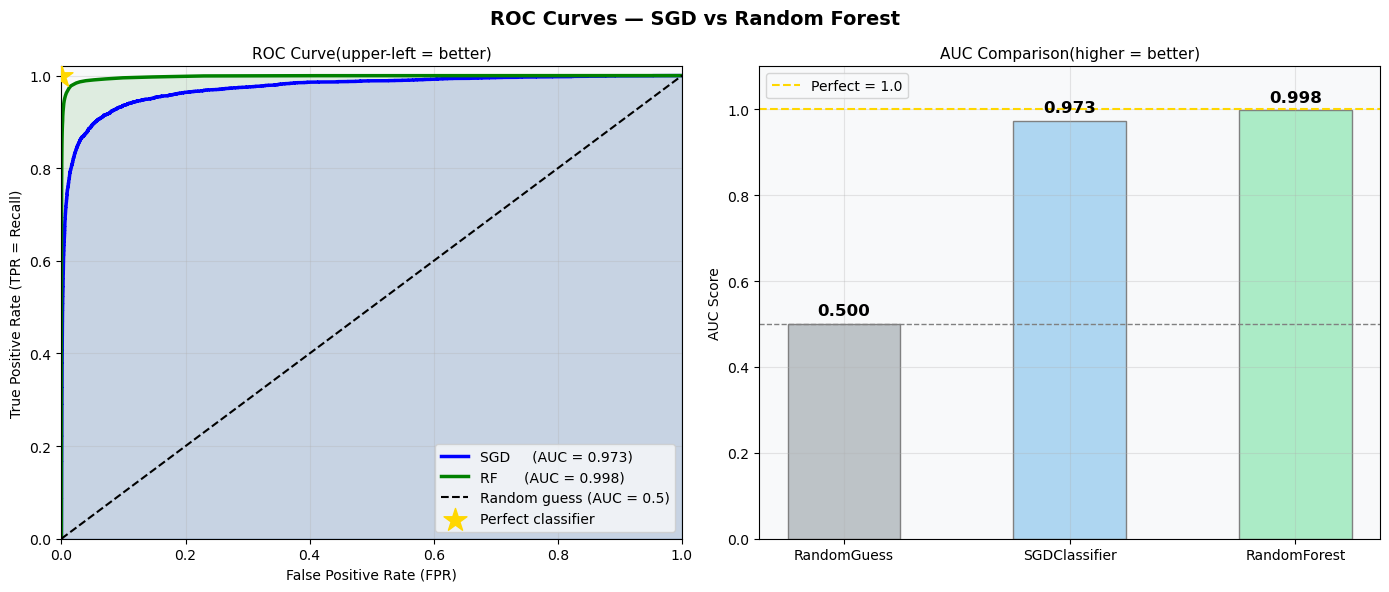

🏆 Random Forest wins: AUC = 0.998 vs SGD AUC = 0.973
   Difference: 2.5 percentage points


In [11]:
# ROC Curve comparison: SGD vs Random Forest
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict

print("Training Random Forest for comparison (takes ~20 seconds)...")
rf_clf = RandomForestClassifier(n_estimators=50,   # 50 trees in the forest
                                random_state=42,   # Fixed seed for reproducibility
                                n_jobs=-1)         # Use all available CPU cores to speed up training
y_probas_rf = cross_val_predict(rf_clf, X_train, y_train_5, cv=3,
                                 method='predict_proba')[:, 1]
# predict_proba → returns probability estimates: [[P(not 5), P(is 5)], ...]
# [:, 1]        → take only the second column = P(is 5), the positive class probability

# Compute the ROC curve for each model
fpr_sgd, tpr_sgd, _ = roc_curve(y_train_5, y_scores)
# roc_curve(true_labels, scores) → returns (FPR array, TPR array, thresholds array)
# FPR = False Positive Rate = FP / (FP + TN)
# TPR = True Positive Rate  = TP / (TP + FN) = Recall
# _ → we discard the thresholds (don't need them for the plot)
fpr_rf,  tpr_rf,  _ = roc_curve(y_train_5, y_probas_rf)  # Same for Random Forest

# Compute a single AUC score for each model
auc_sgd = roc_auc_score(y_train_5, y_scores)       # AUC = area under the SGD ROC curve
auc_rf  = roc_auc_score(y_train_5, y_probas_rf)   # AUC = area under the RF ROC curve
# AUC = 1.0 → perfect | AUC = 0.5 → random guessing | AUC < 0.5 → worse than random

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ROC Curves — SGD vs Random Forest", fontsize=14, fontweight='bold')

# ── Left: ROC curve ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(fpr_sgd, tpr_sgd, 'b-', lw=2.5, label=f'SGD     (AUC = {auc_sgd:.3f})')
ax.plot(fpr_rf,  tpr_rf,  'g-', lw=2.5, label=f'RF      (AUC = {auc_rf:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random guess (AUC = 0.5)')  # Diagonal = no skill
ax.fill_between(fpr_rf,  tpr_rf,  alpha=0.1, color='green')   # Shade area under RF curve
ax.fill_between(fpr_sgd, tpr_sgd, alpha=0.1, color='blue')    # Shade area under SGD curve

ax.scatter([0], [1], marker='*', s=300, color='gold', zorder=5, label='Perfect classifier')
# A perfect classifier would sit at top-left: FPR=0, TPR=1
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR = Recall)")
ax.set_title("ROC Curve(upper-left = better)", fontsize=11)
ax.legend(); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

# ── Right: AUC bar chart for quick comparison ────────────────────────────
ax = axes[1]
models_names  = ['RandomGuess', 'SGDClassifier', 'RandomForest']
auc_values    = [0.5, auc_sgd, auc_rf]              # AUC scores for each model
bar_colors    = ['#BDC3C7', '#AED6F1', '#ABEBC6']   # Grey, blue, green
bars = ax.bar(models_names, auc_values, color=bar_colors, edgecolor='gray', width=0.5)
ax.axhline(0.5, color='gray', lw=1, linestyle='--')                # Baseline: random guessing
ax.axhline(1.0, color='gold', lw=1.5, linestyle='--', label='Perfect = 1.0')  # Ceiling: perfect
ax.set_ylim(0, 1.1); ax.set_ylabel("AUC Score")
ax.set_title("AUC Comparison(higher = better)", fontsize=11)
for bar, val in zip(bars, auc_values):               # Annotate each bar with its AUC value
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig("ch03_07_roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"🏆 Random Forest wins: AUC = {auc_rf:.3f} vs SGD AUC = {auc_sgd:.3f}")
print(f"   Difference: {(auc_rf - auc_sgd)*100:.1f} percentage points")


## 6. 🔟 Multiclass Classification

Now we classify all 10 digits (0–9) instead of just "5 or not".

> 🟦 **Multiclass Classification:** Classifying instances into more than two classes.

### Strategies for algorithms that only support binary:

| Strategy | How it works | Classifiers needed |
|---|---|---|
| **OvR (One vs Rest)** | Train one binary classifier per class | 10 classifiers |
| **OvO (One vs One)** | Train one classifier for every pair | 10×9/2 = 45 classifiers |

> 🟨 **Key Takeaway:** Scikit-Learn handles this automatically! Most classifiers support multiclass out of the box. It defaults to OvR for most, OvO for SVMs.


Training SGD on all 10 digit classes...
✅ Training accuracy: 90.14%
   Test accuracy:     89.33%


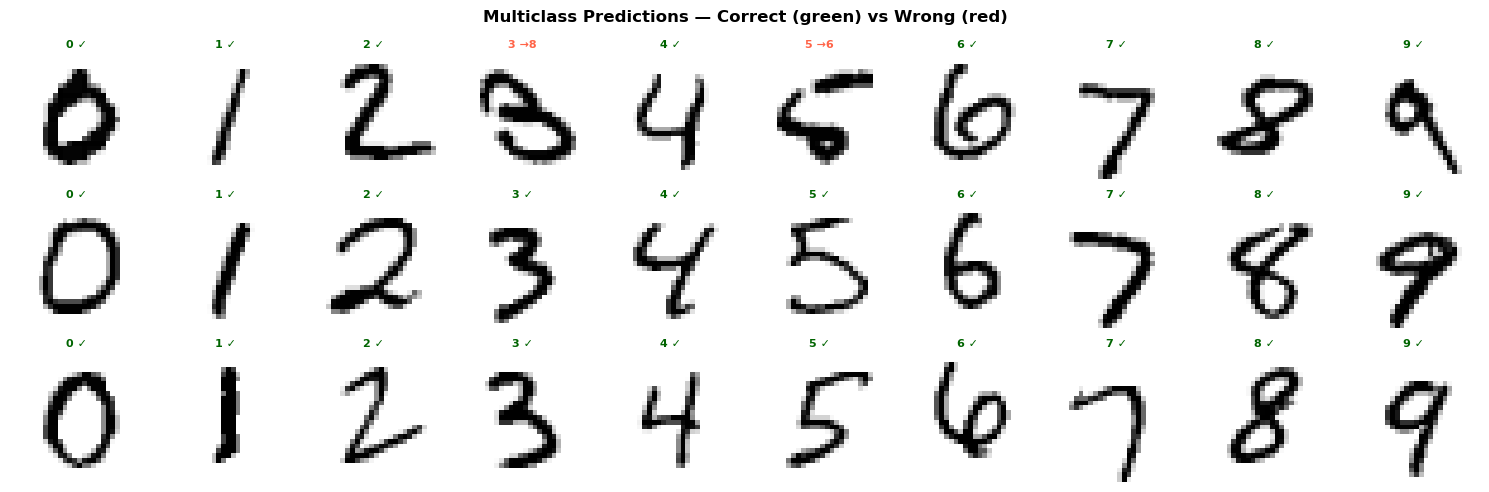

In [12]:
# Train a multiclass classifier on all 10 digits (0–9)
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("Training SGD on all 10 digit classes...")
sgd_multi = Pipeline([
    ('scaler', StandardScaler()),                         # Scale pixels: mean=0, std=1 per feature
    ('sgd', SGDClassifier(random_state=42, max_iter=1000))# SGD handles multiclass via OvR by default
])
# Scikit-Learn automatically uses One-vs-Rest (OvR) for SGD:
# it trains 10 binary classifiers ("is it a 0?", "is it a 1?", ... "is it a 9?")
# then picks the class with the highest confidence score

sgd_multi.fit(X_train, y_train)  # Train on the full 10-class labels (not binary)

# Evaluate accuracy on both sets
train_acc = sgd_multi.score(X_train, y_train)  # .score() returns accuracy by default
test_acc  = sgd_multi.score(X_test,  y_test)
print(f"✅ Training accuracy: {train_acc*100:.2f}%")
print(f"   Test accuracy:     {test_acc*100:.2f}%")

# Visualise predictions on a sample of test images
fig, axes = plt.subplots(3, 10, figsize=(15, 5))  # 3 rows × 10 columns (one per digit)
fig.suptitle("Multiclass Predictions — Correct (green) vs Wrong (red)", fontsize=12, fontweight='bold')

for digit in range(10):                              # For each digit class
    idxs = np.where(y_test == digit)[0][:3]          # Get first 3 test images of this digit
    for row, idx in enumerate(idxs):
        ax = axes[row, digit]
        ax.imshow(X_test[idx].reshape(28, 28), cmap='binary')  # Show the image
        ax.axis('off')
        pred = sgd_multi.predict([X_test[idx]])[0]   # Predict the digit class
        correct = (pred == digit)                    # Was the prediction right?
        color  = 'darkgreen' if correct else 'tomato'# Green if correct, red if wrong
        symbol = '✓' if correct else f'→{pred}'     # Show tick or the wrong prediction
        ax.set_title(f'{digit} {symbol}', fontsize=8,
                     color=color, fontweight='bold', pad=1)

plt.tight_layout()
plt.savefig("ch03_08_multi_predictions.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Multiclass confusion matrix — the most informative visualisation for 10-class problems
from sklearn.model_selection import cross_val_predict  # For fair out-of-fold predictions
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("Generating cross-validated predictions for confusion matrix...")
y_train_pred_multi = cross_val_predict(sgd_multi, X_train, y_train, cv=3)
# cv=3 → split into 3 folds; each sample is predicted exactly once by a model that never saw it
# This gives us honest predictions for all 60,000 training images

cm_multi = confusion_matrix(y_train, y_train_pred_multi)
# Returns a 10×10 matrix: cm_multi[i, j] = number of times true=i was predicted as j
# Diagonal cells (i==j) = correct predictions; off-diagonal = errors

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Multiclass Confusion Matrix — 10-Digit Classification", fontsize=13, fontweight='bold')

# ── Left: raw counts ─────────────────────────────────────────────────────
ax = axes[0]
sns.heatmap(cm_multi,
            annot=True,            # Show the number inside each cell
            fmt='d',               # Format as integer (not scientific notation)
            cmap='Blues',          # Darker blue = higher count
            ax=ax,
            xticklabels=range(10), # x-axis labels = predicted digit
            yticklabels=range(10)) # y-axis labels = true digit
ax.set_title("Raw Counts", fontsize=12)
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")

# ── Right: error rates only (diagonal removed) ───────────────────────────
cm_errors = cm_multi.astype(float)          # Convert to float so we can divide without integer rounding
np.fill_diagonal(cm_errors, 0)              # Zero out the diagonal — correct predictions aren't errors
row_sums = cm_multi.sum(axis=1, keepdims=True)  # Total actual samples per class (row sum)
cm_errors_norm = cm_errors / row_sums       # Divide each cell by its row total → fraction of that class misclassified

ax = axes[1]
sns.heatmap(cm_errors_norm,
            annot=True,            # Show values inside cells
            fmt='.2%',             # Format as percentage (e.g. 1.23%)
            cmap='Reds',           # Brighter red = higher error rate
            ax=ax,
            xticklabels=range(10),
            yticklabels=range(10))
ax.set_title("Error Rates Only(diagonal zeroed — brighter = more confused)", fontsize=12)
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")

plt.tight_layout()
plt.savefig("ch03_09_multiclass_cm.png", dpi=150, bbox_inches='tight')
plt.show()

print("💡 Reading the error matrix:")
print("   Row = True label | Column = Predicted label")
print("   Bright cell at (True=8, Pred=3) means: the model often confuses 8s with 3s")


Generating cross-validated predictions for confusion matrix...


## 7. 🔬 Error Analysis

Once you have a confusion matrix, dig into the actual mistakes. Look at:
- Which classes are most confused with each other?
- Is there a pattern in the misclassified images?
- Can you engineer features to fix those specific errors?

> 🟨 **Key Takeaway:** The confusion matrix tells you **what** is going wrong. Looking at individual errors tells you **why** — and what to fix.


In [ ]:
# Visualise specific errors — what does the model get confused about?
import matplotlib.pyplot as plt
import numpy as np

def plot_digits(instances, images_per_row=10, **options):
    # Helper: arrange multiple flat digit vectors into one big grid image
    size = 28                                          # Each image is 28×28 pixels
    images_per_row = min(len(instances), images_per_row)  # Cap columns at available images
    n_rows = (len(instances) - 1) // images_per_row + 1   # Calculate how many rows we need
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)    # Padding to fill the last row
    instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)
    # Append blank (zero) images to fill any empty slots in the grid
    for row in range(n_rows):
        rimages = instances[row * images_per_row: (row + 1) * images_per_row]  # Get images for this row
        row_images.append(np.concatenate(rimages.reshape(-1, size, size), axis=1))
        # reshape(-1, 28, 28) → convert flat vectors to 2D images
        # concatenate along axis=1 → place images side by side horizontally
    image = np.concatenate(row_images, axis=0)            # Stack all rows vertically into one big image
    return image

# Build a sorted list of the most common confusion pairs
error_pairs = []
for true_digit in range(10):
    for pred_digit in range(10):
        if true_digit != pred_digit:                       # Skip diagonal (correct predictions)
            rate = cm_errors_norm[true_digit, pred_digit] # Error rate for this (true, predicted) pair
            error_pairs.append((rate, true_digit, pred_digit))
error_pairs.sort(reverse=True)                            # Sort descending: worst confusions first

print("Top 5 most confused digit pairs:")
for rate, true_d, pred_d in error_pairs[:5]:
    print(f"  True={true_d} → Predicted={pred_d}: {rate*100:.1f}% of actual {true_d}s misclassified")

# Visualise the worst confusion pair in detail
rate, true_d, pred_d = error_pairs[0]                     # Most confused pair
true_mask  = (y_train == true_d)  & (y_train_pred_multi == pred_d)
# Boolean mask: rows where the true label is true_d AND the prediction was wrong (pred_d)
false_mask = (y_train == pred_d)  & (y_train_pred_multi == true_d)
# Reverse confusion: true label is pred_d, predicted as true_d

X_true_confused  = X_train[true_mask][:25]   # Up to 25 examples of the first error type
X_false_confused = X_train[false_mask][:25]  # Up to 25 examples of the reverse error

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Error Analysis: Most Confused Pair — {true_d}s vs {pred_d}s",
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.imshow(plot_digits(X_true_confused), cmap='binary', interpolation='nearest')
# Show the mosaic of misclassified images
ax.set_title(f"True {true_d}s predicted as {pred_d}(false negatives for {true_d})",
             fontsize=11, color='tomato')
ax.axis('off')

ax = axes[1]
ax.imshow(plot_digits(X_false_confused), cmap='binary', interpolation='nearest')
ax.set_title(f"True {pred_d}s predicted as {true_d}(false positives for {true_d})",
             fontsize=11, color='steelblue')
ax.axis('off')

plt.tight_layout()
plt.savefig("ch03_10_error_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"💡 Can you see why the model confuses {true_d}s and {pred_d}s?")
print("   They share similar curves/strokes — better preprocessing or augmentation could help!")


## 8. 📋 The Full Classification Report

Scikit-Learn's `classification_report` gives precision, recall, and F1 for every class at once.

> 🟦 **Macro Average:** Average the metric across classes, treating each class equally (regardless of how many samples it has).

> 🟦 **Weighted Average:** Average weighted by each class's sample count. Better for imbalanced datasets.


In [ ]:
# Full classification report — precision, recall and F1 for every class
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get the full report as a dictionary (easier to plot)
report = classification_report(y_train, y_train_pred_multi, output_dict=True)
# output_dict=True → return a dict instead of a formatted string, so we can put it in a DataFrame
report_df = pd.DataFrame(report).T.drop(['accuracy', 'macro avg', 'weighted avg'])
# pd.DataFrame(report).T → transpose so rows = classes, columns = metrics
# .drop([...])           → remove the summary rows — we only want per-digit rows
report_df = report_df.astype(float)   # Ensure all values are numeric (not strings)

print("Classification Report:")
print(classification_report(y_train, y_train_pred_multi))  # Print the human-readable table

# ── Bar chart: per-digit precision, recall and F1 ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(10)    # x positions for each digit (0–9)
width = 0.25         # Width of each bar; three bars per digit so 0.25 each fits nicely

# Plot three grouped bars per digit
bars1 = ax.bar(x - width, report_df['precision'], width, label='Precision',
               color='#AED6F1', edgecolor='white')   # Shift left by one bar width
bars2 = ax.bar(x,          report_df['recall'],   width, label='Recall',
               color='#ABEBC6', edgecolor='white')   # Centred
bars3 = ax.bar(x + width,  report_df['f1-score'], width, label='F1 Score',
               color='#FAD7A0', edgecolor='white')   # Shift right by one bar width

ax.set_xticks(x)                                     # Place a tick at each digit position
ax.set_xticklabels([f'Digit {i}' for i in range(10)], rotation=20)  # Label each tick
ax.set_ylabel("Score"); ax.set_ylim(0, 1.1)
ax.set_title("Per-Class Precision, Recall & F1 Score — All 10 Digits",
             fontsize=12, fontweight='bold')
ax.legend()
ax.axhline(0.85, color='gray', lw=1, linestyle='--', alpha=0.5)  # Reference line at 85%

# Highlight any scores below 80% in red so weak classes stand out
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()           # Score value for this bar
        if h < 0.80:                   # Flag weak performance
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.2f}', ha='center', fontsize=7.5, color='tomato', fontweight='bold')

plt.tight_layout()
plt.savefig("ch03_11_classification_report.png", dpi=150, bbox_inches='tight')
plt.show()
print("💡 Lower scores on a digit means the model struggles with that digit.")
print("   Check which digit has the lowest F1 and investigate why in the error analysis.")


## 9. 🏷️ Multilabel Classification

> 🟦 **Multilabel Classification:** Each instance can belong to **multiple classes simultaneously**.

**Real-world examples:**
- A photo can contain both a cat AND a dog → two labels at once
- An email can be both spam AND urgent
- A news article can be tagged science, AI, AND technology

**Example on MNIST:** Predict both "is it large (≥7)?" AND "is it odd?" for each digit.


In [ ]:
# Multilabel classification — each image gets TWO labels simultaneously
from sklearn.neighbors import KNeighborsClassifier  # KNN supports multilabel out of the box
import numpy as np

# Create two independent binary labels for each training image
y_train_large = (y_train >= 7)        # Label 1: Is it a "large" digit? (7, 8, or 9)
y_train_odd   = (y_train % 2 == 1)   # Label 2: Is it an odd digit? (1, 3, 5, 7, 9)
y_multilabel  = np.column_stack([y_train_large, y_train_odd])
# np.column_stack → combine two 1D arrays into a 2D array with shape (60000, 2)
# Each row = [is_large, is_odd] for one image

print("Multilabel examples:")
for digit in range(10):
    idx   = np.where(y_train == digit)[0][0]  # Get the first training image of this digit
    large = y_train_large[idx]                # Look up its "large" label
    odd   = y_train_odd[idx]                  # Look up its "odd" label
    print(f"  Digit {digit}: large={large}, odd={odd}")

# Train a KNN multilabel classifier
print("Training KNN multilabel classifier...")
knn_clf = KNeighborsClassifier(n_neighbors=3,  # Use 3 nearest neighbours for majority vote
                               n_jobs=-1)      # Parallelise across all CPU cores
knn_clf.fit(X_train[:10000], y_multilabel[:10000])
# We train on only the first 10,000 samples to keep this fast (KNN is slow on large data)
# In production you'd train on all 60,000

# Predict both labels at once for a test image
test_img = X_test[y_test == 3][0]            # Grab the first test image of digit '3'
pred = knn_clf.predict([test_img])            # Returns shape (1, 2): [[is_large, is_odd]]
print(f"Prediction for digit '3':")
print(f"  Is large (≥7)? {pred[0][0]}  (expected: False ✅)")  # 3 < 7, so not large
print(f"  Is odd?        {pred[0][1]}  (expected: True ✅)")   # 3 is odd


## 📖 Chapter 3 Key Terminology Glossary

| Term | Simple Definition |
|---|---|
| **Binary Classification** | Predict one of exactly two classes (Yes/No, Spam/Not Spam) |
| **Multiclass Classification** | Predict one of three or more classes (digits 0–9) |
| **Multilabel Classification** | Each instance can have multiple labels simultaneously |
| **Confusion Matrix** | Table of TP, TN, FP, FN — the complete picture of classification errors |
| **True Positive (TP)** | Correctly predicted positive |
| **False Positive (FP)** | Predicted positive, actually negative (Type I Error) |
| **False Negative (FN)** | Predicted negative, actually positive (Type II Error) |
| **True Negative (TN)** | Correctly predicted negative |
| **Precision** | Of all predicted positives, what fraction were actually positive? |
| **Recall (Sensitivity)** | Of all actual positives, what fraction did we catch? |
| **F1 Score** | Harmonic mean of precision and recall |
| **ROC Curve** | Plot of TPR vs FPR at every threshold |
| **AUC** | Area under the ROC curve — single number summarising classifier quality |
| **Decision Threshold** | Score cutoff above which we predict positive |
| **PR Curve** | Precision vs Recall at every threshold — better for imbalanced classes |
| **OvR (One vs Rest)** | Binary classifier per class — "Is this a 5?" × 10 times |
| **SGD Classifier** | Fast linear classifier trained with stochastic gradient descent |
| **Class Imbalance** | When one class has many more samples than another |
| **MNIST** | Benchmark dataset of 70k handwritten digit images |

---

## 🟨 Chapter 3 Key Takeaways

> 1. **Accuracy is misleading** on imbalanced datasets — always check precision, recall, F1
> 2. **Confusion matrix** gives the full picture of what the model gets right and wrong
> 3. **Precision vs Recall tradeoff** — you control it via the decision threshold
> 4. **ROC/AUC** compares classifiers across all thresholds; use PR curve for imbalanced data
> 5. **Error analysis** — look at actual misclassified images to find the pattern behind errors
> 6. **Scikit-Learn handles multiclass automatically** using OvR or OvO strategies
> 7. **Multilabel classification** allows one instance to belong to multiple classes

---
*Next up → Chapter 4: Training Models (Linear & Logistic Regression, Gradient Descent) 📉*
